In [32]:
!git clone https://github.com/TranQuan231005/Computer_Vision_Lab


fatal: destination path 'Computer_Vision_Lab' already exists and is not an empty directory.


In [5]:
!pip install opencv-python numpy matplotlib


In [7]:
import os
print(os.getcwd())

/content


In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Đọc ảnh
img_path = "Computer_Vision_Lab/Lap1/images/input/sample.jpg"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def show_img(images, title="Result"): # Added title parameter for flexibility
  if images is None:
      print("Không thể hiển thị ảnh: ảnh đầu vào là None.")
  else:
      print(f"Hiển thị ảnh thành công! Kích thước: {images.shape}")

      # Hiển thị ảnh trong Notebook, sử dụng cmap='gray' cho ảnh grayscale

      plt.title(title)
      plt.imshow(images, cmap='gray')
      plt.axis('off')



 # Phát hiện cạnh cơ bản (Basic Edge Detection)





### **3.1 Toán tử Sobel & Prewitt**




Hiển thị ảnh thành công! Kích thước: (739, 415)
Hiển thị ảnh thành công! Kích thước: (739, 415)


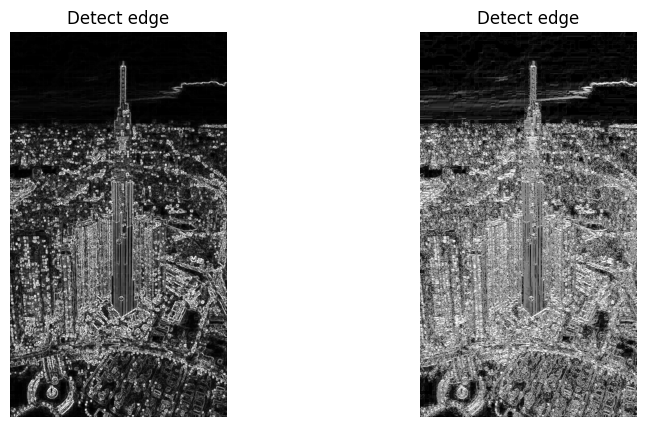

In [71]:

# Sobel
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Absolute value
abs_sobel_x = cv2.convertScaleAbs(sobel_x)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine x, y
sobel_combine = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

kernel_prewitt_x = np.array([[-9, -12, 5],
                             [-1, 0, 1],
                             [-5, 12, 9]])

kernel_prewitt_y = np.array([[-1, -1, -1],
                              [0, 0, 0],
                              [1, 1, 1]])

# Apply convoluation by cv2.filter2D
prewitt_x = cv2.filter2D(gray, cv2.CV_64F, kernel_prewitt_x)
prewitt_y = cv2.filter2D(gray, cv2.CV_64F, kernel_prewitt_y)

# absolute value
abs_prewitt_x = cv2.convertScaleAbs(prewitt_x)
abs_prewitt_y = cv2.convertScaleAbs(prewitt_y)

# Combine x, y
prewitt_combine = cv2.addWeighted(abs_prewitt_x, 0.5, abs_prewitt_y, 0.5, 0)

# Show
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
show_img(sobel_combine, title="Detect edge")
plt.subplot(1, 3, 2)
show_img(prewitt_combine, title="Detect edge")

### **3.3 Non-Linear**

#### **Median Filter**

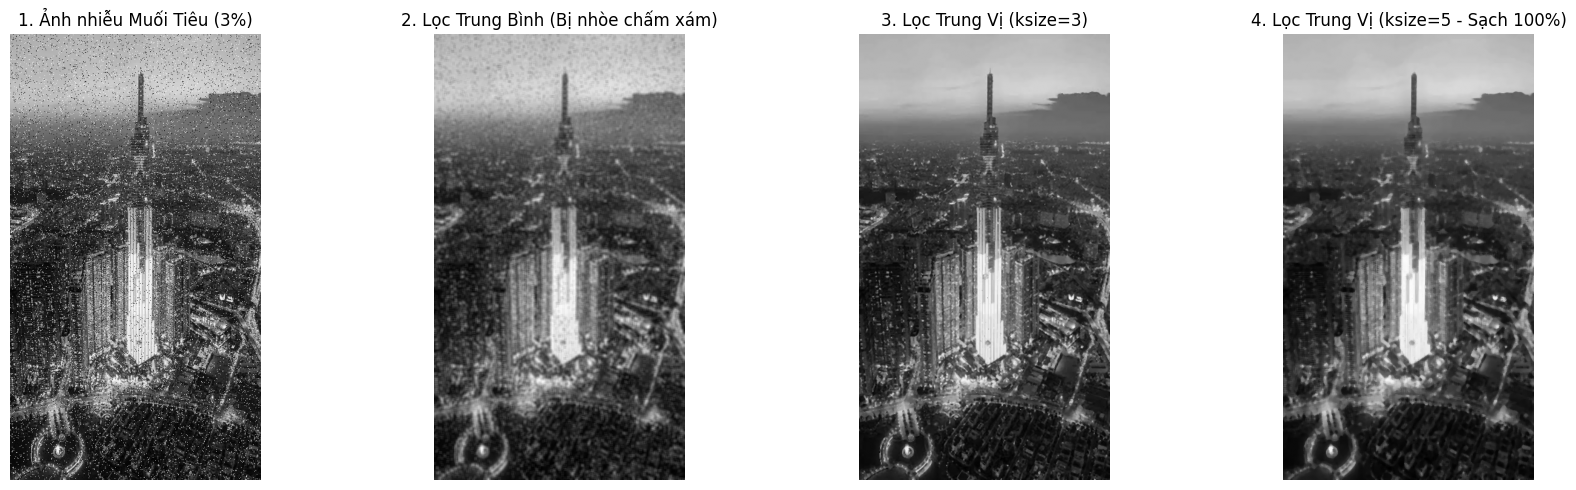

In [73]:
# 1. Hàm tạo nhiễu muối tiêu (Salt & Pepper Noise)
def add_salt_pepper_noise(image, salt_ratio=0.02, pepper_ratio=0.02):
    noisy_img = image.copy()
    num_salt = np.ceil(salt_ratio * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255  # Hạt muối trắng

    num_pepper = np.ceil(pepper_ratio * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0    # Hạt tiêu đen
    return noisy_img

# Tạo ảnh bị nhiễu
noisy_landmark = add_salt_pepper_noise(gray, salt_ratio=0.03, pepper_ratio=0.03)

# 2. So sánh: Lọc trung bình (Mean Blur) vs Lọc trung vị (Median Blur)
mean_filtered = cv2.blur(noisy_landmark, (5, 5))
median_filtered_3 = cv2.medianBlur(noisy_landmark, 3)
median_filtered_5 = cv2.medianBlur(noisy_landmark, 5)

# 3. Hiển thị
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(noisy_landmark, cmap='gray')
plt.title("1. Ảnh nhiễu Muối Tiêu (3%)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title("2. Lọc Trung Bình (Bị nhòe chấm xám)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(median_filtered_3, cmap='gray')
plt.title("3. Lọc Trung Vị (ksize=3)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(median_filtered_5, cmap='gray')
plt.title("4. Lọc Trung Vị (ksize=5 - Sạch 100%)")
plt.axis('off')

plt.tight_layout()
plt.show()


#### **Bilateral filter.**

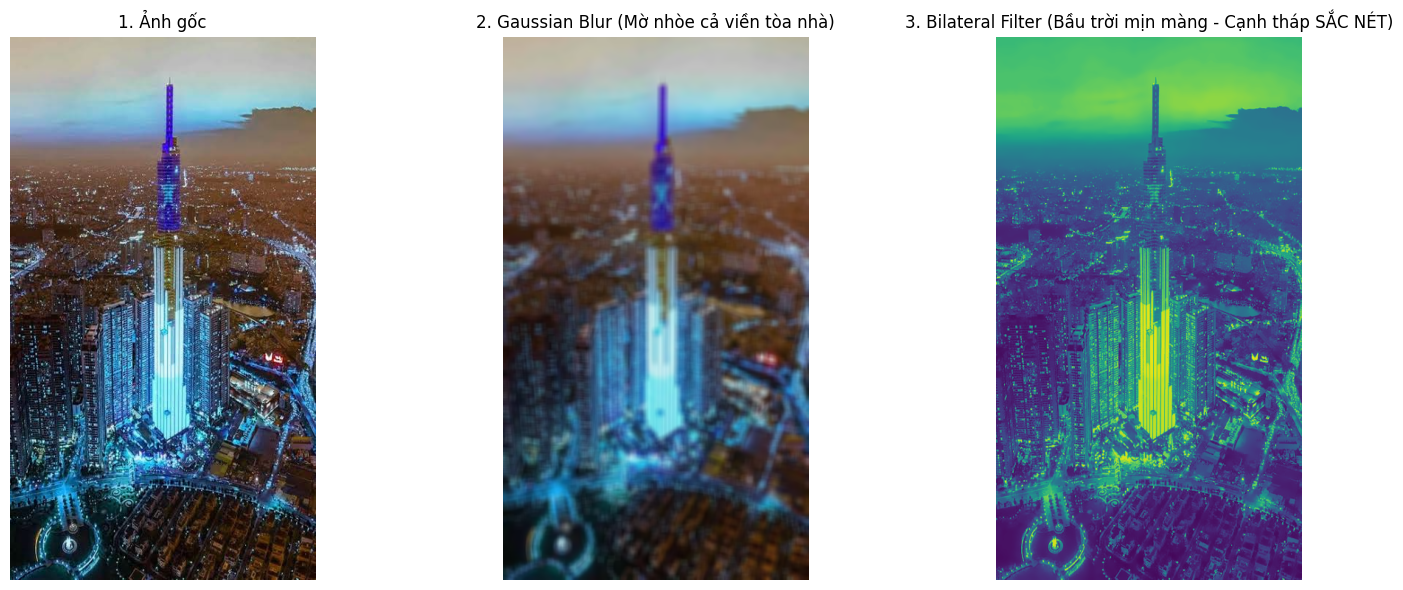

In [92]:
# 1. Lọc Gaussian (làm mờ toàn bộ)
gaussian_smooth = cv2.GaussianBlur(img, (9, 9), sigmaX=75)

# 2. Lọc Bilateral (d: đường kính lân cận, sigmaColor: độ lọc màu, sigmaSpace: độ lọc khoảng cách)
bilateral_smooth = cv2.bilateralFilter(gray, d=10, sigmaColor=11, sigmaSpace=10)

# 3. Hiển thị so sánh
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
#plt.imshow(gray, cmap='gray')
plt.imshow(img)
plt.title("1. Ảnh gốc", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
#plt.imshow(gaussian_smooth, cmap='gray')
plt.imshow(gaussian_smooth)
plt.title("2. Gaussian Blur (Mờ nhòe cả viền tòa nhà)", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
#plt.imshow(bilateral_smooth, cmap='gray')
plt.imshow(bilateral_smooth)
plt.title("3. Bilateral Filter (Bầu trời mịn màng - Cạnh tháp SẮC NÉT)", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()


### **5. BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC BỘ LỌC**

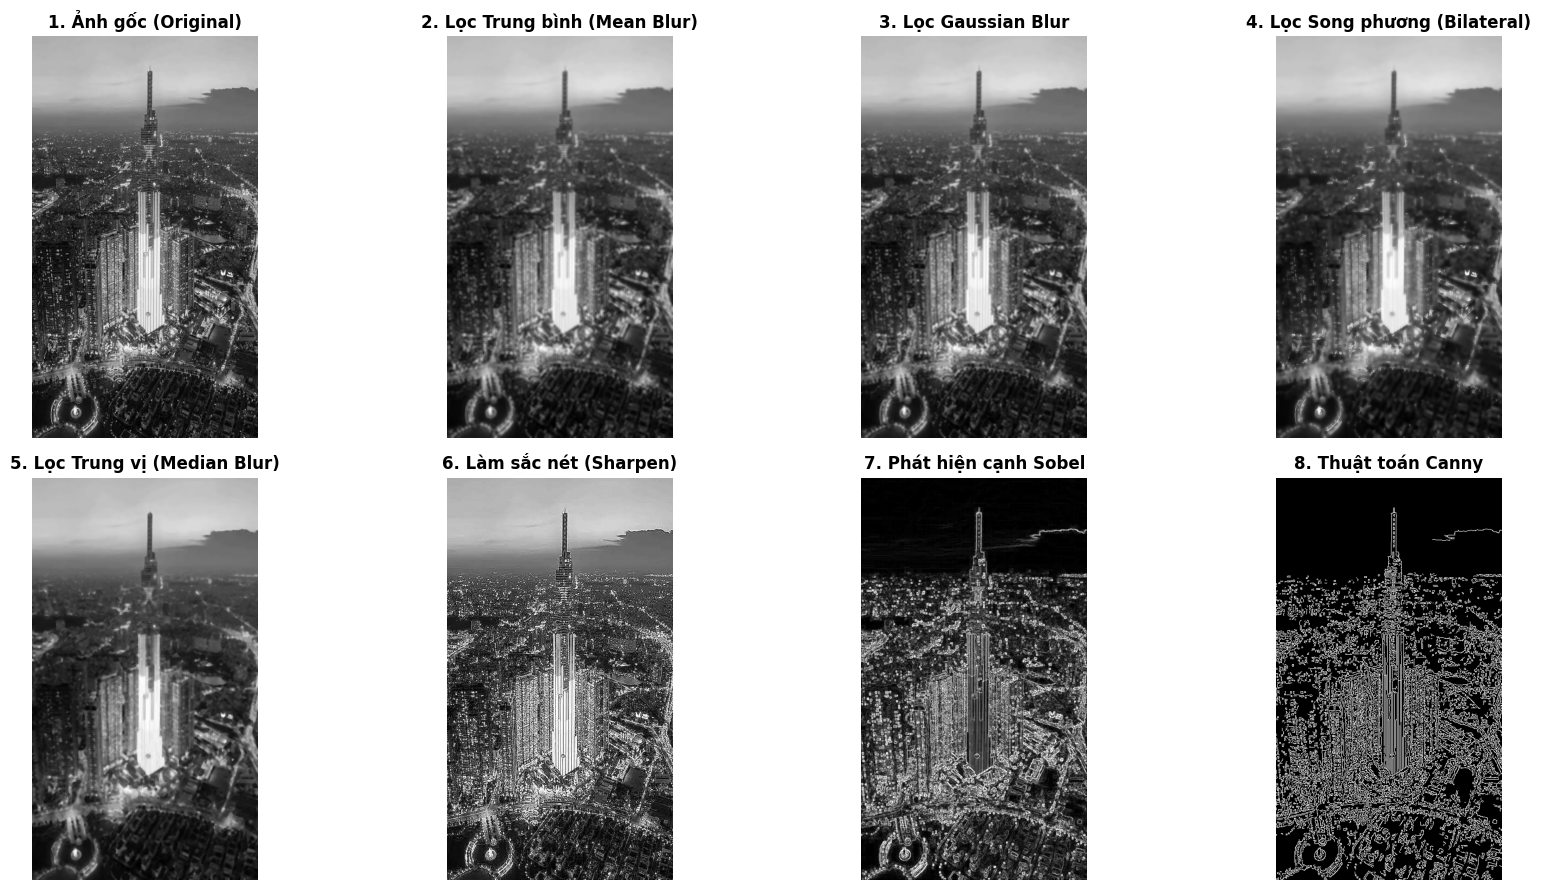

In [72]:
# 1. Ảnh gốc
img_orig = gray.copy()

# 2. LỌC TUYẾN TÍNH (Linear Filters)
# 2.1. Lọc trung bình (Mean / Average Blur)
img_mean = cv2.blur(gray, (5, 5))

# 2.2. Lọc Gaussian (Gaussian Blur)
img_gaussian = cv2.GaussianBlur(gray, (5, 5), sigmaX=1.5)

# 2.3. Lọc làm sắc nét (Sharpening qua kernel Laplacian)
kernel_sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
img_sharpen = cv2.convertScaleAbs(cv2.filter2D(gray, cv2.CV_64F, kernel_sharp))

# 3. LỌC PHI TUYẾN TÍNH (Non-Linear Filters)
# 3.1. Lọc trung vị (Median Filter)
img_median = cv2.medianBlur(gray, 5)

# 3.2. Lọc song phương (Bilateral Filter - Giữ cạnh)
img_bilateral = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# 4. LỌC PHÁT HIỆN CẠNH (Edge Detection Filters)
# 4.1. Toán tử Sobel (Đạo hàm bậc 1 có làm mịn)
sx = cv2.convertScaleAbs(cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3))
sy = cv2.convertScaleAbs(cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3))
img_sobel = cv2.addWeighted(sx, 0.5, sy, 0.5, 0)

# 4.2. Toán tử Canny (Thuật toán phát hiện cạnh tối ưu)
img_canny = cv2.Canny(gray, threshold1=100, threshold2=200)


# ================== HIỂN THỊ LƯỚI SO SÁNH (2x4) ==================
filters_list = [
    (img_orig, "1. Ảnh gốc (Original)"),
    (img_mean, "2. Lọc Trung bình (Mean Blur)"),
    (img_gaussian, "3. Lọc Gaussian Blur"),
    (img_bilateral, "4. Lọc Song phương (Bilateral)"),
    (img_median, "5. Lọc Trung vị (Median Blur)"),
    (img_sharpen, "6. Làm sắc nét (Sharpen)"),
    (img_sobel, "7. Phát hiện cạnh Sobel"),
    (img_canny, "8. Thuật toán Canny")
]

plt.figure(figsize=(18, 9))
for idx, (im, title) in enumerate(filters_list):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(im, cmap='gray')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [93]:
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
